# RQ3 Evaluation


In [78]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [92]:
N_REQUESTED = 189
N_RUNS = 3

SYNTHETIC_TRANSCRIPTS_FILE = Path(
    "/home/jovyan/Exploring-LLM-Based-Feature-Extraction-for-"
    "Depression-Assessment-from-Therapy-Transcripts/"
    "OUTPUT/10_synthetic_transcripts_long.csv"
)

SYNTHETIC_ERRORS_FILE = Path(
    "/home/jovyan/Exploring-LLM-Based-Feature-Extraction-for-"
    "Depression-Assessment-from-Therapy-Transcripts/"
    "OUTPUT/synthetic_transcripts_errors.csv"
)

SYNTHETIC_PREDICTIONS_FILE = Path(
    "/home/jovyan/Exploring-LLM-Based-Feature-Extraction-for-"
    "Depression-Assessment-from-Therapy-Transcripts/"
    "OUTPUT/synthetic_indirect_no_reasoning_long.csv"
)

REAL_PREDICTIONS_FILE = Path(
    "/home/jovyan/"
    "Exploring-LLM-Based-Feature-Extraction-for-Depression-Assessment-from-"
    "Therapy-Transcripts/OUTPUT/phq8_complete_transcript_3_runs_long.csv"
)

META_FILE = Path(
    "/home/jovyan/Exploring-LLM-Based-Feature-Extraction-for-"
    "Depression-Assessment-from-Therapy-Transcripts/"
    "INPUT/DAIC_META.csv"
)

OUTPUT_DIR = Path(
    "/home/jovyan/Exploring-LLM-Based-Feature-Extraction-for-"
    "Depression-Assessment-from-Therapy-Transcripts/"
    "OUTPUT/RQ3_EVALUATION"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [80]:
PHQ8_ITEM_MAP = {
    "phq8_nointerest": "target_PHQ8_NoInterest",
    "phq8_depressed": "target_PHQ8_Depressed",
    "phq8_sleep": "target_PHQ8_Sleep",
    "phq8_tired": "target_PHQ8_Tired",
    "phq8_appetite": "target_PHQ8_Appetite",
    "phq8_failure": "target_PHQ8_Failure",
    "phq8_concentrating": "target_PHQ8_Concentrating",
    "phq8_moving": "target_PHQ8_Moving",
}

SEVERITY_BINS = [-1, 4, 9, 14, 24]

SEVERITY_LABELS = [
    "Minimal 0-4",
    "Mild 5-9",
    "Moderate 10-14",
    "High 15+",
]


In [81]:
def calculate_prediction_metrics(df, true_col, predicted_col):
    valid = df[[true_col, predicted_col]].dropna()

    mae = mean_absolute_error(
        valid[true_col],
        valid[predicted_col]
    )

    rmse = np.sqrt(
        mean_squared_error(
            valid[true_col],
            valid[predicted_col]
        )
    )

    pearson_r, pearson_p = pearsonr(
        valid[true_col],
        valid[predicted_col]
    )

    spearman_r, spearman_p = spearmanr(
        valid[true_col],
        valid[predicted_col]
    )

    return {
        "n": len(valid),
        "MAE": mae,
        "RMSE": rmse,
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_r": spearman_r,
        "Spearman_p": spearman_p,
    }


def calculate_alternation_rate(group):
    speakers = group["speaker"].reset_index(drop=True)

    if len(speakers) < 2:
        return np.nan

    return (
        speakers.iloc[1:].reset_index(drop=True)
        != speakers.iloc[:-1].reset_index(drop=True)
    ).mean()


def count_words(text):
    return len(str(text).split())


## 3. Generation Summary


In [82]:
synthetic_transcripts = pd.read_csv(
    SYNTHETIC_TRANSCRIPTS_FILE
)

if SYNTHETIC_ERRORS_FILE.exists():
    synthetic_errors = pd.read_csv(
        SYNTHETIC_ERRORS_FILE
    )
else:
    synthetic_errors = pd.DataFrame(
        columns=["synthetic_id", "error"]
    )

usable_ids = set(
    synthetic_transcripts["synthetic_id"]
    .dropna()
    .unique()
)

generation_summary = pd.DataFrame({
    "Metric": [
        "Requested transcripts",
        "Usable transcripts",
        "Failed transcripts",
        "Generation success rate",
    ],
    "Value": [
        N_REQUESTED,
        len(usable_ids),
        N_REQUESTED - len(usable_ids),
        len(usable_ids) / N_REQUESTED,
    ],
})
display(generation_summary)


,Metric,Value
0,Requested transcripts,189.000000
1,Usable transcripts,187.000000
2,Failed transcripts,2.000000
3,Generation success rate,0.989418


## 4. Descriptives


In [83]:
synthetic_transcripts["word_count"] = (
    synthetic_transcripts["value"]
    .apply(count_words)
)

transcript_summary = (
    synthetic_transcripts
    .groupby("synthetic_id")
    .agg(
        target_phq=("target_PHQ8_Score", "first"),
        n_utterances=("value", "size"),
        total_words=("word_count", "sum"),
        participant_utterances=(
            "speaker",
            lambda x: (x == "Participant").sum()
        ),
        therapist_utterances=(
            "speaker",
            lambda x: (x == "Therapist").sum()
        ),
    )
    .reset_index()
)

alternation_rates = (
    synthetic_transcripts
    .groupby("synthetic_id", sort=False)
    .apply(calculate_alternation_rate)
    .rename("speaker_alternation_rate")
    .reset_index()
)

transcript_summary = transcript_summary.merge(
    alternation_rates,
    on="synthetic_id",
    how="left"
)

display(
    transcript_summary[
        [
            "n_utterances",
            "total_words",
            "participant_utterances",
            "therapist_utterances",
            "speaker_alternation_rate",
        ]
    ].describe()
)


,n_utterances,total_words,participant_utterances,therapist_utterances,speaker_alternation_rate
count,187.000000,187.000000,187.000000,187.000000,187.000000
mean,223.187166,1952.759358,111.326203,111.860963,0.998160
std,53.744940,427.821540,26.837935,26.970153,0.012096
min,124.000000,1011.000000,62.000000,62.000000,0.843137
25%,183.000000,1660.500000,91.000000,91.500000,1.000000
50%,223.000000,1880.000000,111.000000,112.000000,1.000000
75%,254.000000,2178.000000,127.000000,127.500000,1.000000
max,505.000000,4137.000000,250.000000,255.000000,1.000000


In [84]:
synthetic_predictions = pd.read_csv(
    SYNTHETIC_PREDICTIONS_FILE
)

synthetic_predictions["run_id"] = pd.to_numeric(
    synthetic_predictions["run_id"],
    errors="coerce"
)

synthetic_predictions["phq_score_indirect"] = pd.to_numeric(
    synthetic_predictions["phq_score_indirect"],
    errors="coerce"
)

for item_col in PHQ8_ITEM_MAP:
    synthetic_predictions[item_col] = pd.to_numeric(
        synthetic_predictions[item_col],
        errors="coerce"
    )

synthetic_predictions = synthetic_predictions[
    synthetic_predictions["run_id"].isin(
        range(1, N_RUNS + 1)
    )
].copy()

synthetic_predictions = (
    synthetic_predictions
    .sort_values(["synthetic_id", "run_id"])
    .drop_duplicates(
        subset=["synthetic_id", "run_id"],
        keep="last"
    )
)

synthetic_predictions.shape


(561, 24)

In [85]:
parse_summary = (
    synthetic_predictions
    .groupby("run_id")
    .agg(
        n_outputs=("synthetic_id", "size"),
        n_valid=("phq_score_indirect", "count"),
    )
    .reset_index()
)

parse_summary["valid_rate"] = (
    parse_summary["n_valid"]
    / parse_summary["n_outputs"]
)

display(parse_summary)

parse_summary.to_csv(
    OUTPUT_DIR / "synthetic_parse_summary.csv",
    index=False
)


,run_id,n_outputs,n_valid,valid_rate
0,1,187,187,1.0
1,2,187,187,1.0
2,3,187,187,1.0


In [86]:
synthetic_targets = (
    synthetic_transcripts
    .groupby("synthetic_id")
    .agg(
        target_phq=("target_PHQ8_Score", "first"),
        **{
            target_col: (target_col, "first")
            for target_col in PHQ8_ITEM_MAP.values()
        }
    )
    .reset_index()
)

synthetic_eval = (
    synthetic_predictions
    .groupby("synthetic_id")
    .agg(
        predicted_phq_mean=(
            "phq_score_indirect",
            "mean"
        ),
        predicted_phq_std=(
            "phq_score_indirect",
            "std"
        ),
        predicted_phq_median=(
            "phq_score_indirect",
            "median"
        ),
        valid_runs=(
            "phq_score_indirect",
            "count"
        ),
        **{
            f"{item_col}_mean": (
                item_col,
                "mean"
            )
            for item_col in PHQ8_ITEM_MAP
        }
    )
    .reset_index()
)

synthetic_eval = synthetic_targets.merge(
    synthetic_eval,
    on="synthetic_id",
    how="inner"
)

synthetic_eval_complete = synthetic_eval[
    synthetic_eval["valid_runs"] == N_RUNS
].copy()

synthetic_eval_complete["error"] = (
    synthetic_eval_complete["predicted_phq_mean"]
    - synthetic_eval_complete["target_phq"]
)

synthetic_eval_complete["absolute_error"] = (
    synthetic_eval_complete["error"].abs()
)

display(
    synthetic_eval_complete[
        [
            "synthetic_id",
            "target_phq",
            "predicted_phq_mean",
            "predicted_phq_std",
            "valid_runs",
            "error",
            "absolute_error",
        ]
    ].head()
)

print(
    "Vollständige Fälle:",
    len(synthetic_eval_complete)
)


,synthetic_id,target_phq,predicted_phq_mean,predicted_phq_std,valid_runs,error,absolute_error
0,syn_0000,13,12.666667,0.577350,3,-0.333333,0.333333
1,syn_0001,11,8.000000,1.000000,3,-3.000000,3.000000
2,syn_0002,12,9.333333,0.577350,3,-2.666667,2.666667
3,syn_0003,8,9.333333,0.577350,3,1.333333,1.333333
4,syn_0004,15,13.000000,1.732051,3,-2.000000,2.000000


Vollständige Fälle: 187


In [87]:
synthetic_metrics = calculate_prediction_metrics(
    synthetic_eval_complete,
    true_col="target_phq",
    predicted_col="predicted_phq_mean"
)

synthetic_metrics_df = pd.DataFrame(
    [synthetic_metrics]
)

display(synthetic_metrics_df)


,n,MAE,RMSE,Pearson_r,Pearson_p,Spearman_r,Spearman_p
0,187,2.490196,3.133493,0.542958,9.915353e-16,0.469389,1.231139e-11


In [88]:
synthetic_predictions_with_targets = (
    synthetic_predictions
    .merge(
        synthetic_targets[
            ["synthetic_id", "target_phq"]
        ],
        on="synthetic_id",
        how="left"
    )
)

run_results = []

for run_id, run_df in synthetic_predictions_with_targets.groupby(
    "run_id"
):
    metrics = calculate_prediction_metrics(
        run_df,
        true_col="target_phq",
        predicted_col="phq_score_indirect"
    )

    metrics["run_id"] = int(run_id)
    run_results.append(metrics)

synthetic_run_results = pd.DataFrame(
    run_results
)[
    [
        "run_id",
        "n",
        "MAE",
        "RMSE",
        "Pearson_r",
        "Pearson_p",
        "Spearman_r",
        "Spearman_p",
    ]
]

display(synthetic_run_results)


,run_id,n,MAE,RMSE,Pearson_r,Pearson_p,Spearman_r,Spearman_p
0,1,187,2.593583,3.303701,0.507291,1.270281e-13,0.440360,2.850405e-10
1,2,187,2.657754,3.339122,0.520086,2.377058e-14,0.429845,8.285432e-10
2,3,187,2.497326,3.223410,0.534659,3.228672e-15,0.496945,4.683849e-13


In [89]:
item_results = []

for predicted_item, target_item in PHQ8_ITEM_MAP.items():
    metrics = calculate_prediction_metrics(
        synthetic_eval_complete,
        true_col=target_item,
        predicted_col=f"{predicted_item}_mean"
    )

    metrics["item"] = predicted_item
    item_results.append(metrics)

synthetic_item_metrics = pd.DataFrame(
    item_results
)[
    [
        "item",
        "n",
        "MAE",
        "RMSE",
        "Pearson_r",
        "Pearson_p",
        "Spearman_r",
        "Spearman_p",
    ]
]

display(synthetic_item_metrics)


,item,n,MAE,RMSE,Pearson_r,Pearson_p,Spearman_r,Spearman_p
0,phq8_nointerest,187,0.590018,0.815404,0.739160,1.390396e-33,0.740557,9.095805e-34
1,phq8_depressed,187,0.474153,0.711505,0.791924,1.719457e-41,0.776316,6.281877e-39
2,phq8_sleep,187,0.385027,0.604007,0.844850,3.854603e-52,0.819103,1.593880e-46
3,phq8_tired,187,0.508021,0.736535,0.789262,4.872776e-41,0.782317,6.882364e-40
4,phq8_appetite,187,0.506239,0.759961,0.748919,6.769480e-35,0.697354,1.453066e-28
5,phq8_failure,187,0.461676,0.696737,0.801610,3.401710e-43,0.808457,1.860212e-44
6,phq8_concentrating,187,0.454545,0.662644,0.811817,4.279326e-45,0.779324,2.091929e-39
7,phq8_moving,187,0.397504,0.602530,0.836337,3.551537e-50,0.822668,3.018256e-47


In [90]:
synthetic_eval_complete["severity_group"] = pd.cut(
    synthetic_eval_complete["target_phq"],
    bins=SEVERITY_BINS,
    labels=SEVERITY_LABELS
)

synthetic_by_severity = (
    synthetic_eval_complete
    .groupby(
        "severity_group",
        observed=False
    )
    .agg(
        n=("absolute_error", "size"),
        MAE=("absolute_error", "mean"),
        median_absolute_error=(
            "absolute_error",
            "median"
        ),
    )
    .reset_index()
)

display(synthetic_by_severity)


,severity_group,n,MAE,median_absolute_error
0,Minimal 0-4,2,1.833333,1.833333
1,Mild 5-9,43,2.674419,2.000000
2,Moderate 10-14,103,2.300971,2.000000
3,High 15+,39,2.820513,2.666667


In [94]:
real_predictions = pd.read_csv(
    REAL_PREDICTIONS_FILE
)

real_predictions["run_id"] = pd.to_numeric(
    real_predictions["run_id"],
    errors="coerce"
)

real_predictions["row_idx"] = pd.to_numeric(
    real_predictions.index,
    errors="coerce"
)

real_predictions["phq_score_indirect"] = pd.to_numeric(
    real_predictions["phq_score_indirect"],
    errors="coerce"
)

real_predictions = real_predictions[
    real_predictions["run_id"].isin(
        range(1, N_RUNS + 1)
    )
].copy()

real_full_context = (
    real_predictions
    .sort_values(
        [
            "Participant_ID",
            "run_id",
            "row_idx",
        ]
    )
    .groupby(
        [
            "Participant_ID",
            "run_id",
        ],
        as_index=False
    )
    .tail(1)
)

real_full_context.shape


(567, 15)

In [95]:
real_eval = (
    real_full_context
    .groupby("Participant_ID")
    .agg(
        predicted_phq_mean=(
            "phq_score_indirect",
            "mean"
        ),
        predicted_phq_std=(
            "phq_score_indirect",
            "std"
        ),
        predicted_phq_median=(
            "phq_score_indirect",
            "median"
        ),
        valid_runs=(
            "phq_score_indirect",
            "count"
        ),
    )
    .reset_index()
)

meta = pd.read_csv(META_FILE)

real_eval = real_eval.merge(
    meta[
        [
            "Participant_ID",
            "PHQ_Score",
        ]
    ],
    on="Participant_ID",
    how="left"
)

real_eval_complete = real_eval[
    real_eval["valid_runs"] == N_RUNS
].copy()

real_eval_complete["error"] = (
    real_eval_complete["predicted_phq_mean"]
    - real_eval_complete["PHQ_Score"]
)

real_eval_complete["absolute_error"] = (
    real_eval_complete["error"].abs()
)

display(real_eval_complete.head())

print(
    "Vollständige reale Fälle:",
    len(real_eval_complete)
)


,Participant_ID,predicted_phq_mean,predicted_phq_std,predicted_phq_median,valid_runs,PHQ_Score,error,absolute_error
0,300,0.000000,0.000000,0.0,3,2,-2.000000,2.000000
1,301,0.000000,0.000000,0.0,3,3,-3.000000,3.000000
2,302,2.333333,0.577350,2.0,3,4,-1.666667,1.666667
3,303,0.666667,0.577350,1.0,3,0,0.666667,0.666667
4,304,2.333333,1.154701,3.0,3,6,-3.666667,3.666667


Vollständige reale Fälle: 189


In [96]:
real_metrics = calculate_prediction_metrics(
    real_eval_complete,
    true_col="PHQ_Score",
    predicted_col="predicted_phq_mean"
)

real_metrics_df = pd.DataFrame(
    [real_metrics]
)

display(real_metrics_df)


,n,MAE,RMSE,Pearson_r,Pearson_p,Spearman_r,Spearman_p
0,189,3.693122,5.134293,0.696784,8.587530e-29,0.713893,9.387743e-31


In [97]:
real_eval_complete["severity_group"] = pd.cut(
    real_eval_complete["PHQ_Score"],
    bins=SEVERITY_BINS,
    labels=SEVERITY_LABELS
)

real_by_severity = (
    real_eval_complete
    .groupby(
        "severity_group",
        observed=False
    )
    .agg(
        n=("absolute_error", "size"),
        MAE=("absolute_error", "mean"),
        median_absolute_error=(
            "absolute_error",
            "median"
        ),
    )
    .reset_index()
)

severity_comparison = synthetic_by_severity.merge(
    real_by_severity,
    on="severity_group",
    suffixes=("_synthetic", "_real")
)

display(severity_comparison)


,severity_group,n_synthetic,MAE_synthetic,median_absolute_error_synthetic,n_real,MAE_real,median_absolute_error_real
0,Minimal 0-4,2,1.833333,1.833333,86,1.368217,1.000000
1,Mild 5-9,43,2.674419,2.000000,46,2.992754,2.666667
2,Moderate 10-14,103,2.300971,2.000000,30,5.411111,5.666667
3,High 15+,39,2.820513,2.666667,27,10.382716,10.000000


In [ ]:
overall_comparison = pd.DataFrame([
    {
        "dataset": "Synthetic",
        **synthetic_metrics,
    },
    {
        "dataset": "Real",
        **real_metrics,
    },
])

display(overall_comparison)


,dataset,n,MAE,RMSE,Pearson_r,Pearson_p,Spearman_r,Spearman_p
0,Synthetic,187,2.490196,3.133493,0.542958,9.915353e-16,0.469389,1.231139e-11
1,Real,188,3.648936,5.014164,0.719473,2.890108e-31,0.725544,5.198876e-32


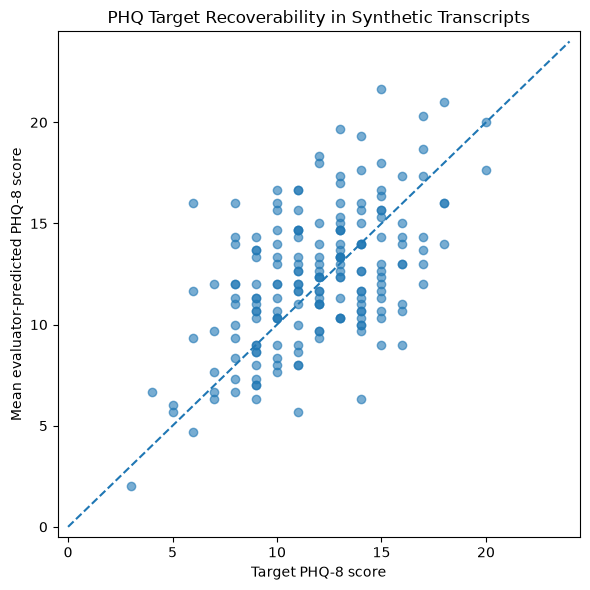

In [ ]:
plt.figure(figsize=(6, 6))

plt.scatter(
    synthetic_eval_complete["target_phq"],
    synthetic_eval_complete["predicted_phq_mean"],
    alpha=0.6
)

plt.plot(
    [0, 24],
    [0, 24],
    linestyle="--"
)

plt.xlim(-0.5, 24.5)
plt.ylim(-0.5, 24.5)

plt.xlabel("Target PHQ-8 score")
plt.ylabel("Mean evaluator-predicted PHQ-8 score")
plt.title("PHQ Target Recoverability in Synthetic Transcripts")

plt.tight_layout()

plt.show()
